# Single-Run Evaluation Analysis

Coverage by schema for each dataset, broken down by generation model.

**Source:** `outputs/evaluation/single_run/{evaluator}/{generator}/{dataset}/evaluation.json`

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

%matplotlib inline

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
SINGLE_RUN_DIR = ROOT / "outputs" / "evaluation" / "single_run"
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Publication-quality settings (fits a two-column IEEE/ACM paper)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Load data

In [6]:
records = []
for path in sorted(SINGLE_RUN_DIR.glob("**/evaluation.json")):
    # path: single_run/{evaluator}/{generator}/{dataset}/evaluation.json
    dataset   = path.parent.name
    generator = path.parent.parent.name
    evaluator = path.parent.parent.parent.name
    ed = json.loads(path.read_text())
    for schema in ed["evaluations"]:
        cov, hc = [], []
        for expert in schema["experts"]:
            t = expert["total_questions"]
            if t:
                cov.append(expert["covered_questions"] / t)
                hc.append(expert["high_confidence"] / t)
        if cov:
            records.append({
                "evaluator":    evaluator,
                "generator":    generator,
                "dataset":      dataset,
                "schema_index": schema["schema_index"],
                "num_fields":   schema["num_fields"],
                "coverage":     float(np.mean(cov)),
                "high_conf":    float(np.mean(hc)),
            })

df = pd.DataFrame(records)
print(
    f"{len(df)} schema evaluations · "
    f"{df['dataset'].nunique()} dataset(s) · "
    f"{df['generator'].nunique()} generator model(s)"
)
df.head()

18 schema evaluations · 2 dataset(s) · 1 generator model(s)


,evaluator,generator,dataset,schema_index,num_fields,coverage,high_conf
0,gpt-5.4-mini,gpt-5.4-nano,pl_age,0,1,0.645846,0.601401
1,gpt-5.4-mini,gpt-5.4-nano,pl_age,1,1,0.669670,0.585485
2,gpt-5.4-mini,gpt-5.4-nano,pl_age,2,1,0.750651,0.633133
3,gpt-5.4-mini,gpt-5.4-nano,pl_age,3,1,0.807307,0.770771
4,gpt-5.4-mini,gpt-5.4-nano,pl_age,4,1,0.917918,0.770771


## Table — coverage by schema

In [7]:
table = (
    df[["dataset", "generator", "schema_index", "num_fields", "coverage", "high_conf"]]
    .sort_values(["dataset", "generator", "schema_index"])
    .reset_index(drop=True)
)
table.index += 1

styled = (
    table.style
    .format({
        "num_fields": "{:.0f}",
        "coverage":   "{:.1%}",
        "high_conf":  "{:.1%}",
    })
    .background_gradient(subset=["coverage", "high_conf"], cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption(
        "Coverage and high-confidence rate per schema (mean across expert question sets)."
    )
    .set_table_styles([
        {"selector": "caption", "props": "font-size:0.85em; text-align:left; padding-bottom:4px;"},
        {"selector": "th", "props": "text-align:center; font-weight:bold;"},
        {"selector": "td", "props": "text-align:center;"},
    ])
)
display(styled)

# LaTeX export for paper
latex = (
    table
    .assign(
        coverage=lambda d: d["coverage"].map("{:.1%}".format),
        high_conf=lambda d: d["high_conf"].map("{:.1%}".format),
        num_fields=lambda d: d["num_fields"].astype(int),
    )
    .rename(columns={
        "dataset": "Dataset",
        "generator": "Generator",
        "schema_index": "Schema",
        "num_fields": "Fields",
        "coverage": "Coverage",
        "high_conf": "High conf.",
    })
    .to_latex(index=False, column_format="llccrr")
)
out_tex = FIGURES_DIR / "single_run_coverage_table.tex"
out_tex.write_text(latex)
print(f"LaTeX table saved: {out_tex}")
print(latex)

,dataset,generator,schema_index,num_fields,coverage,high_conf
1,pl_age,gpt-5.4-nano,0,1,64.6%,60.1%
2,pl_age,gpt-5.4-nano,1,1,67.0%,58.5%
3,pl_age,gpt-5.4-nano,2,1,75.1%,63.3%
4,pl_age,gpt-5.4-nano,3,1,80.7%,77.1%
5,pl_age,gpt-5.4-nano,4,1,91.8%,77.1%
6,pl_age,gpt-5.4-nano,5,1,81.6%,78.0%
7,pl_age,gpt-5.4-nano,6,1,89.0%,79.8%
8,pl_age,gpt-5.4-nano,7,1,80.7%,78.7%
9,pl_age,gpt-5.4-nano,8,1,80.7%,78.7%
10,pl_personal_rights,gpt-5.4-nano,0,1,67.1%,64.6%


LaTeX table saved: /home/asawczyn/dev/schematize/outputs/figures/single_run_coverage_table.tex
\begin{tabular}{llccrr}
\toprule
Dataset & Generator & Schema & Fields & Coverage & High conf. \\
\midrule
pl_age & gpt-5.4-nano & 0 & 1 & 64.6% & 60.1% \\
pl_age & gpt-5.4-nano & 1 & 1 & 67.0% & 58.5% \\
pl_age & gpt-5.4-nano & 2 & 1 & 75.1% & 63.3% \\
pl_age & gpt-5.4-nano & 3 & 1 & 80.7% & 77.1% \\
pl_age & gpt-5.4-nano & 4 & 1 & 91.8% & 77.1% \\
pl_age & gpt-5.4-nano & 5 & 1 & 81.6% & 78.0% \\
pl_age & gpt-5.4-nano & 6 & 1 & 89.0% & 79.8% \\
pl_age & gpt-5.4-nano & 7 & 1 & 80.7% & 78.7% \\
pl_age & gpt-5.4-nano & 8 & 1 & 80.7% & 78.7% \\
pl_personal_rights & gpt-5.4-nano & 0 & 1 & 67.1% & 64.6% \\
pl_personal_rights & gpt-5.4-nano & 1 & 1 & 70.3% & 57.7% \\
pl_personal_rights & gpt-5.4-nano & 2 & 1 & 72.9% & 66.5% \\
pl_personal_rights & gpt-5.4-nano & 3 & 1 & 70.5% & 65.5% \\
pl_personal_rights & gpt-5.4-nano & 4 & 1 & 80.8% & 71.9% \\
pl_personal_rights & gpt-5.4-nano & 5 & 1 & 83.4% & 

## Figure — coverage by schema

Saved: /home/asawczyn/dev/schematize/outputs/figures/single_run_coverage_by_schema.pdf


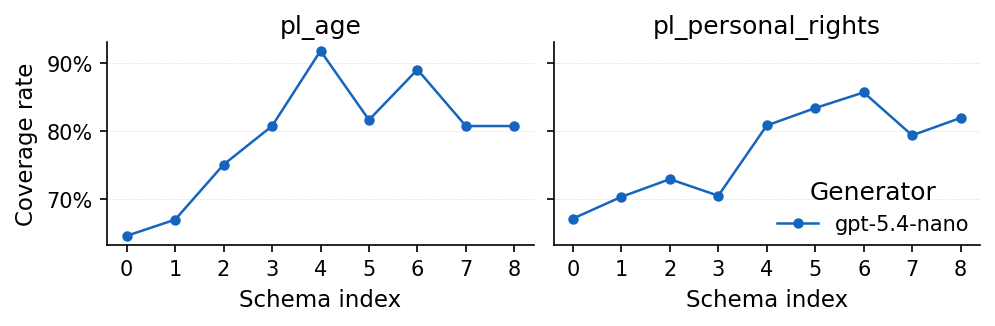

In [8]:
datasets   = sorted(df["dataset"].unique())
generators = sorted(df["generator"].unique())

PALETTE  = ["#1565C0", "#C62828", "#2E7D32", "#6A1B9A", "#00838F"]
MARKERS  = ["o", "s", "^", "D", "v"]
color_map  = {g: PALETTE[i % len(PALETTE)] for i, g in enumerate(generators)}
marker_map = {g: MARKERS[i % len(MARKERS)]  for i, g in enumerate(generators)}

# Width scaled to a single paper column (3.5 in) per subplot; height follows golden ratio
col_w = 3.3
ncols = len(datasets)
fig, axes = plt.subplots(1, ncols, figsize=(col_w * ncols, col_w * 0.65), sharey=True)
if ncols == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub = df[df["dataset"] == dataset]
    for gen in generators:
        g = sub[sub["generator"] == gen].sort_values("schema_index")
        ax.plot(
            g["schema_index"],
            g["coverage"],
            marker=marker_map[gen],
            color=color_map[gen],
            linewidth=1.2,
            markersize=4,
            label=gen,
        )
    ax.set_title(dataset, pad=4)
    ax.set_xlabel("Schema index")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.grid(axis="y", linewidth=0.4, linestyle=":", alpha=0.6)

axes[0].set_ylabel("Coverage rate")

# Single shared legend at top-right of last panel
handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, title="Generator", frameon=False,
                loc="lower right", borderpad=0)

fig.tight_layout(pad=0.5)

out_pdf = FIGURES_DIR / "single_run_coverage_by_schema.pdf"
out_png = FIGURES_DIR / "single_run_coverage_by_schema.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved: {out_pdf}")
plt.show()